In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

In [5]:
df = pd.read_csv("cleaned_superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
print(df.mean(numeric_only=True))
print(df.median(numeric_only=True))
print(df.mode().iloc[0])
print(df.std(numeric_only=True))
print(df.skew(numeric_only=True))

Row ID          4997.500000
Postal Code    55190.379428
Sales            229.858001
Quantity           3.789574
Discount           0.156203
Profit            28.656896
dtype: float64
Row ID          4997.5000
Postal Code    56430.5000
Sales             54.4900
Quantity           3.0000
Discount           0.2000
Profit             8.6665
dtype: float64
Row ID                         1
Order ID          CA-2017-100111
Order Date            2016-09-05
Ship Date             12/16/2015
Ship Mode         Standard Class
Customer ID             WB-21850
Customer Name      William Brown
Segment                 Consumer
Country            United States
City               New York City
State                 California
Postal Code              10035.0
Region                      West
Product ID       OFF-PA-10001970
Category         Office Supplies
Sub-Category             Binders
Product Name     Staple envelope
Sales                      12.96
Quantity                     3.0
Discount           

In [10]:
from scipy.stats import ttest_ind

consumer = df[df['Segment']=='Consumer']['Sales']
corporate = df[df['Segment']=='Corporate']['Sales']

t, p = ttest_ind(consumer, corporate)

print("t-statistic:", t)
print("p-value:", p)

t-statistic: -0.7463917427031926
p-value: 0.4554521800582204


In [11]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Region'], df['Category'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 3.661930938326572
p-value: 0.7223155543986877


In [12]:
import scipy.stats as stats
import numpy as np

sales = df['Sales']

mean = sales.mean()
std = sales.std()

ci = stats.norm.interval(
    0.95,
    loc=mean,
    scale=std/np.sqrt(len(sales))
)

print(ci)

(np.float64(217.63895506136484), np.float64(242.0770465996317))


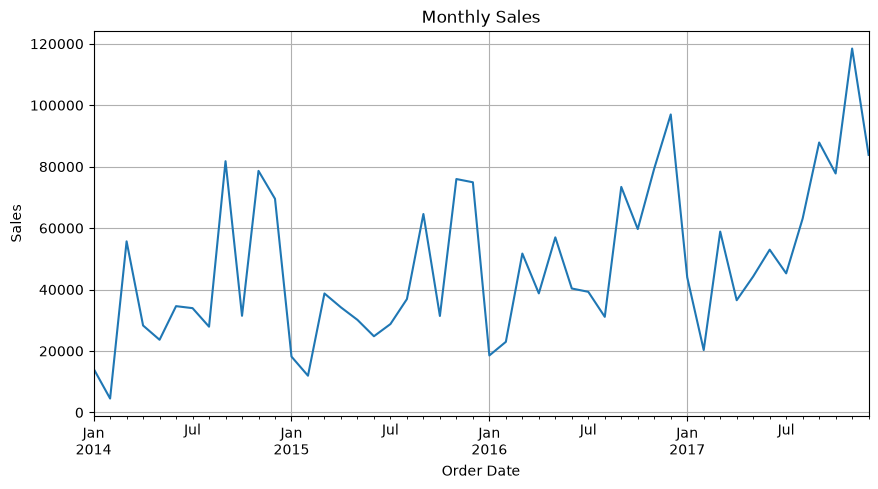

In [16]:
monthly_sales = df['Sales'].resample('ME').sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title("Monthly Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

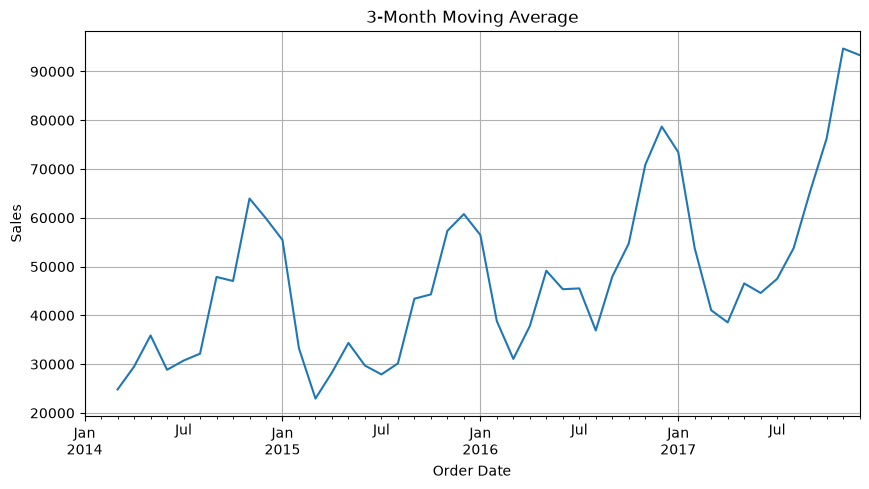

In [17]:
moving_avg = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(10,5))
moving_avg.plot()
plt.title("3-Month Moving Average")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [18]:
X = df[['Sales', 'Quantity', 'Discount', 'Profit']]
print(X.isnull().sum())
X = X.dropna()

Sales       0
Quantity    0
Discount    0
Profit      0
dtype: int64


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

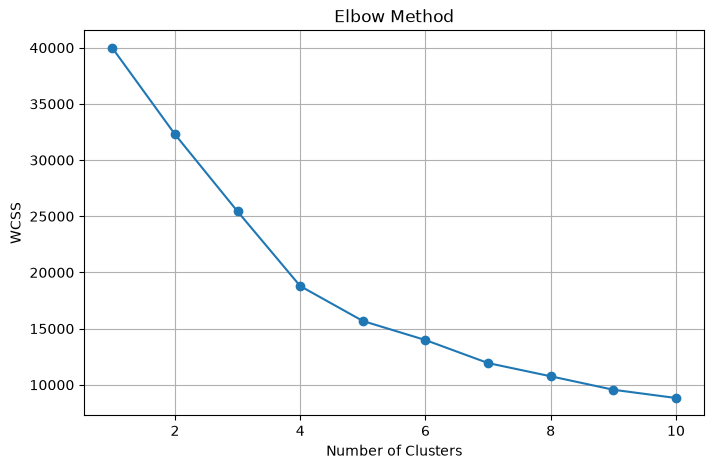

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [21]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [22]:
print(df['Cluster'].value_counts())

Cluster
3    6085
0    2838
1    1044
2      27
Name: count, dtype: int64


In [23]:
cluster_summary = df.groupby('Cluster')[['Sales','Quantity','Discount','Profit']].mean()

print(cluster_summary)

               Sales  Quantity  Discount       Profit
Cluster                                              
0         407.908020  6.452784  0.094655    69.790464
1         153.637349  3.836207  0.667960  -108.306796
2        7685.179259  5.185185  0.070370  2610.220085
3         126.813585  2.533279  0.097487    21.516522


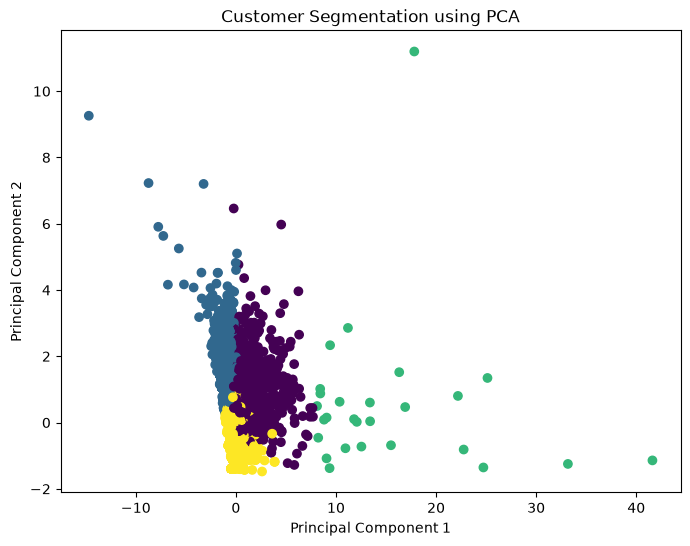

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'])
plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [25]:
X = df[['Sales', 'Quantity', 'Discount']]
y = df['Profit']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.26, -6.51,-208.86]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Sales','Quantity','Discount']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,29.48
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: -0.7240890405096132
MAE: 69.77214730362897
RMSE: 289.12397679271305


In [30]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance = importance.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

print(importance)

    Feature  Coefficient
2  Discount  -208.858709
1  Quantity    -6.512035
0     Sales     0.259335


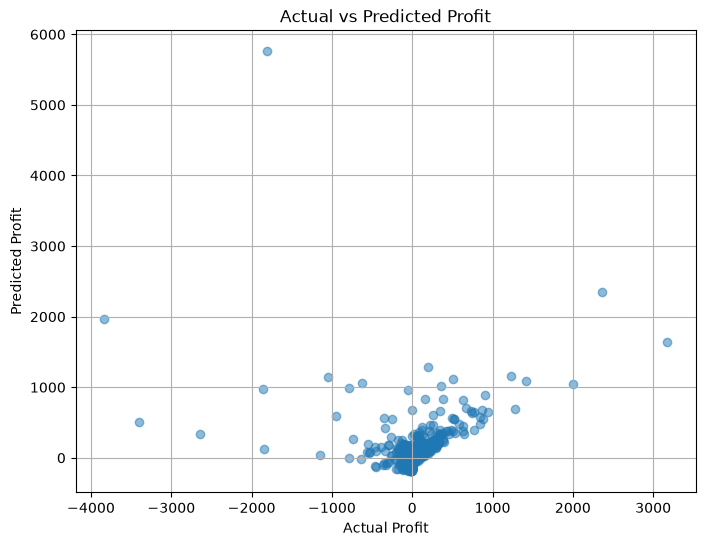

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")
plt.grid(True)
plt.show()

# Business Insights

1. Statistical analysis provided a clear understanding of the distribution of Sales, Quantity, Discount, and Profit, helping identify key business trends.

2. Time series analysis of monthly sales highlighted changes in sales performance over time, enabling the identification of business growth patterns and seasonal variations.

3. Customer segmentation using K-Means clustering grouped records with similar sales and profitability characteristics, which can support targeted marketing strategies and inventory planning.

4. The Linear Regression model identified **Discount** as the most influential feature affecting Profit, with a coefficient of **-208.86**. This indicates that increasing discounts generally leads to a significant reduction in profit.

5. **Quantity** also showed a small negative relationship with Profit (coefficient = **-6.51**), while **Sales** had a positive relationship (coefficient = **0.26**), indicating that increasing sales contributes positively to profit.

6. The model achieved an **R² score of -0.724**, which indicates that the current Linear Regression model does not fit the data well. Additional features or more advanced machine learning models may be required to improve prediction accuracy.

7. The evaluation metrics (**MAE = 69.77** and **RMSE = 289.12**) suggest that prediction errors are relatively high, highlighting opportunities for model improvement.

# Conclusion

This project successfully performed statistical analysis, time series analysis, customer segmentation, and predictive modeling on the Superstore Sales dataset.

The analysis revealed important business patterns in sales, discounts, and profitability. Customer segmentation grouped similar records, which can help businesses design targeted marketing strategies. Time series analysis provided insights into monthly sales trends.

A Linear Regression model was developed to predict Profit using Sales, Quantity, and Discount. The model showed that Discount has the strongest negative impact on Profit, while Sales positively influence Profit. However, the negative R² score indicates that the model is not suitable for accurately predicting Profit using only these three features. Future work should include additional variables and more advanced machine learning algorithms, such as Random Forest Regression or XGBoost, to improve prediction performance.

Overall, this project demonstrates the complete workflow of business data analysis, from statistical exploration to machine learning, and provides valuable insights for data-driven decision-making.